# Tratamiento Inicial de los datos y Analisis exploratorio

# Librerias

In [28]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import pyarrow
from scipy.stats import chi2_contingency

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Funciones

In [3]:
def graficar_multiples_categoricas(df, lista_columnas, cols=2):
    n_vars = len(lista_columnas)
    rows = math.ceil(n_vars / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 7, rows * 5))
    axes = axes.flatten() 

    for i, col in enumerate(lista_columnas):
        order = df[col].value_counts().iloc[:10].index
        
        sns.countplot(
            data=df, 
            y=col, 
            ax=axes[i], 
            order=order, 
            palette="viridis"
        )
        axes[i].set_title(f'Distribución de {col} (Top 10)', fontsize=14)
        axes[i].set_xlabel('Frecuencia')
        axes[i].set_ylabel('')
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [4]:
def analizar_lote_ctr(df, lista_columnas, max_categorias_grafico=20):
    for col in lista_columnas:
        print(f"--- Procesando: {col} ---")
        df_resumen = df.groupby(col)['click'].agg(['mean', 'count']).reset_index()
        df_resumen.columns = [col, 'ctr', 'impresiones']
        if df_resumen.shape[0] > max_categorias_grafico:
            print(f"Nota: {col} tiene {df_resumen.shape[0]} valores. Graficando solo el Top {max_categorias_grafico} por volumen.")
            df_grafico = df_resumen.sort_values(by='impresiones', ascending=False).head(max_categorias_grafico)
        else:
            df_grafico = df_resumen.sort_values(by='ctr', ascending=False)

        plt.figure(figsize=(12, 5))
        sns.barplot(data=df_grafico, x=col, y='ctr', palette='magma')
        
        plt.title(f'CTR por {col}')
        plt.axhline(df['click'].mean(), color='red', linestyle='--', label='CTR Global') 
        plt.xticks(rotation=45)
        plt.ylabel('CTR (Media de clics)')
        plt.show()

In [26]:
def cramers_v_matrix(
    df,
    categorical_cols,
    sample_size=1_000_000,
    random_state=42
):
    # Muestreo para evitar explosión de memoria
    if len(df) > sample_size:
        df = df[categorical_cols].sample(
            n=sample_size,
            random_state=random_state
        )
    else:
        df = df[categorical_cols]

    def cramers_v(x, y):
        contingency = pd.crosstab(x, y)
        chi2 = chi2_contingency(contingency)[0]
        n = contingency.sum().sum()
        r, k = contingency.shape
        return np.sqrt(chi2 / (n * (min(r, k) - 1)))

    n = len(categorical_cols)
    matrix = pd.DataFrame(
        np.zeros((n, n)),
        index=categorical_cols,
        columns=categorical_cols
    )

    for i in range(n):
        for j in range(i, n):
            v = cramers_v(df.iloc[:, i], df.iloc[:, j])
            matrix.iloc[i, j] = v
            matrix.iloc[j, i] = v

    return matrix

# Carga de datos

Se realiza la carga inicial de los datos 

In [5]:
df = pd.read_csv('train.gz')
print(df.head())

             id  click      hour    C1  banner_pos   site_id site_domain  \
0  1.000009e+18      0  14102100  1005           0  1fbe01fe    f3845767   
1  1.000017e+19      0  14102100  1005           0  1fbe01fe    f3845767   
2  1.000037e+19      0  14102100  1005           0  1fbe01fe    f3845767   
3  1.000064e+19      0  14102100  1005           0  1fbe01fe    f3845767   
4  1.000068e+19      0  14102100  1005           1  fe8cc448    9166c161   

  site_category    app_id app_domain  ... device_type device_conn_type    C14  \
0      28905ebd  ecad2386   7801e8d9  ...           1                2  15706   
1      28905ebd  ecad2386   7801e8d9  ...           1                0  15704   
2      28905ebd  ecad2386   7801e8d9  ...           1                0  15704   
3      28905ebd  ecad2386   7801e8d9  ...           1                0  15706   
4      0569f928  ecad2386   7801e8d9  ...           1                0  18993   

   C15  C16   C17  C18  C19     C20  C21  
0  320   50  

Realizamos la observacion inicial para ver si se necesitan transformar algunas variables 

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40428967 entries, 0 to 40428966
Data columns (total 24 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   id                object
 1   click             int64 
 2   hour              int64 
 3   C1                int64 
 4   banner_pos        int64 
 5   site_id           object
 6   site_domain       object
 7   site_category     object
 8   app_id            object
 9   app_domain        object
 10  app_category      object
 11  device_id         object
 12  device_ip         object
 13  device_model      object
 14  device_type       int64 
 15  device_conn_type  int64 
 16  C14               int64 
 17  C15               int64 
 18  C16               int64 
 19  C17               int64 
 20  C18               int64 
 21  C19               int64 
 22  C20               int64 
 23  C21               int64 
dtypes: int64(14), object(10)
memory usage: 7.2+ GB


Podemos observar que algunas de las variables que en el contexto son categoricas, por lo que debemos transformarlas

In [10]:
df['id']=df['id'].astype("str")

In [11]:
df['dt_hour'] = pd.to_datetime(df['hour'], format='%y%m%d%H')

In [12]:
df['dia_semana'] = df['dt_hour'].dt.day_name()
df['hora_del_dia'] = df['dt_hour'].dt.hour
bins = [0, 6, 12, 18, 24]
labels = ['madrugada', 'mañana', 'tarde', 'noche']
df['franja_horaria'] = pd.cut(
    df['dt_hour'].dt.hour,
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)
df['franja_horaria'] = df['franja_horaria'].astype('category')

In [13]:
print(df[['hour', 'dt_hour', 'dia_semana', 'hora_del_dia','franja_horaria']].head())

       hour    dt_hour dia_semana  hora_del_dia franja_horaria
0  14102100 2014-10-21    Tuesday             0      madrugada
1  14102100 2014-10-21    Tuesday             0      madrugada
2  14102100 2014-10-21    Tuesday             0      madrugada
3  14102100 2014-10-21    Tuesday             0      madrugada
4  14102100 2014-10-21    Tuesday             0      madrugada


In [14]:
cols_categoricas = ['C1', 'banner_pos', 'device_type', 'device_conn_type'] + [f'C{i}' for i in range(14, 22)]

for col in cols_categoricas:
    df[col] = df[col].astype('category')

Con las variables transformadas podemos proseguir con el exploratorio

## Analisis exploratorio

Se analiza primero la distribucion de la variable objetivo

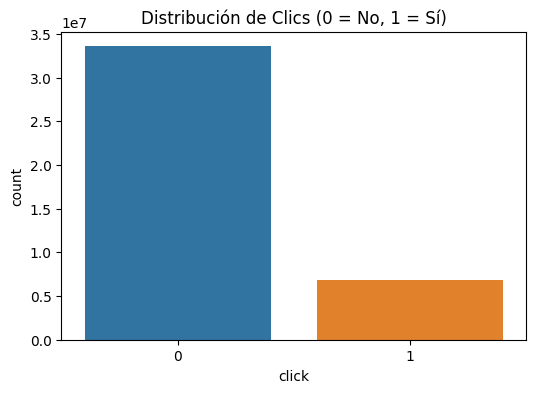

La Tasa de Clic (CTR) global es: 16.98%


In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='click', data=df)
plt.title('Distribución de Clics (0 = No, 1 = Sí)')
plt.show()

ctr_global = df['click'].mean()
print(f"La Tasa de Clic (CTR) global es: {ctr_global:.2%}")

Se puede observar que la varaible objetivo tiene un desbalance bastante notorio en el No, por lo que se tendra que aplicar el balanceo a la hora de realizar el modelo

Se analizan si hay datos faltantes

In [16]:
porcentaje_faltantes = (df.isnull().sum() / len(df)) * 100
print(porcentaje_faltantes)

id                  0.0
click               0.0
hour                0.0
C1                  0.0
banner_pos          0.0
site_id             0.0
site_domain         0.0
site_category       0.0
app_id              0.0
app_domain          0.0
app_category        0.0
device_id           0.0
device_ip           0.0
device_model        0.0
device_type         0.0
device_conn_type    0.0
C14                 0.0
C15                 0.0
C16                 0.0
C17                 0.0
C18                 0.0
C19                 0.0
C20                 0.0
C21                 0.0
dt_hour             0.0
dia_semana          0.0
hora_del_dia        0.0
franja_horaria      0.0
dtype: float64


Podemos observar que no hay datos faltantes, revisamos tambien nuevamente los tipos de datos

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40428967 entries, 0 to 40428966
Data columns (total 28 columns):
 #   Column            Dtype         
---  ------            -----         
 0   id                object        
 1   click             int64         
 2   hour              int64         
 3   C1                category      
 4   banner_pos        category      
 5   site_id           object        
 6   site_domain       object        
 7   site_category     object        
 8   app_id            object        
 9   app_domain        object        
 10  app_category      object        
 11  device_id         object        
 12  device_ip         object        
 13  device_model      object        
 14  device_type       category      
 15  device_conn_type  category      
 16  C14               category      
 17  C15               category      
 18  C16               category      
 19  C17               category      
 20  C18               category      
 21  C19   

Revisamos la cardinalidad de la mayoria de variables

In [18]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns

cardinalidades = df[cat_cols].nunique().sort_values(ascending=False)
cardinalidades.head(10)

id              40428967
device_ip        6729486
device_id        2686408
app_id              8552
device_model        8251
site_domain         7745
site_id             4737
C14                 2626
app_domain           559
C17                  435
dtype: int64

Podemos observar el numero de categorias de cada variable, con algunas que son demasiado numerosas, por lo que se deben tomar con precaucion a la hora de realizar el modelo

Realizamos analisis univariado para variables categoricas 

In [19]:
cat=['device_type','device_conn_type','banner_pos']

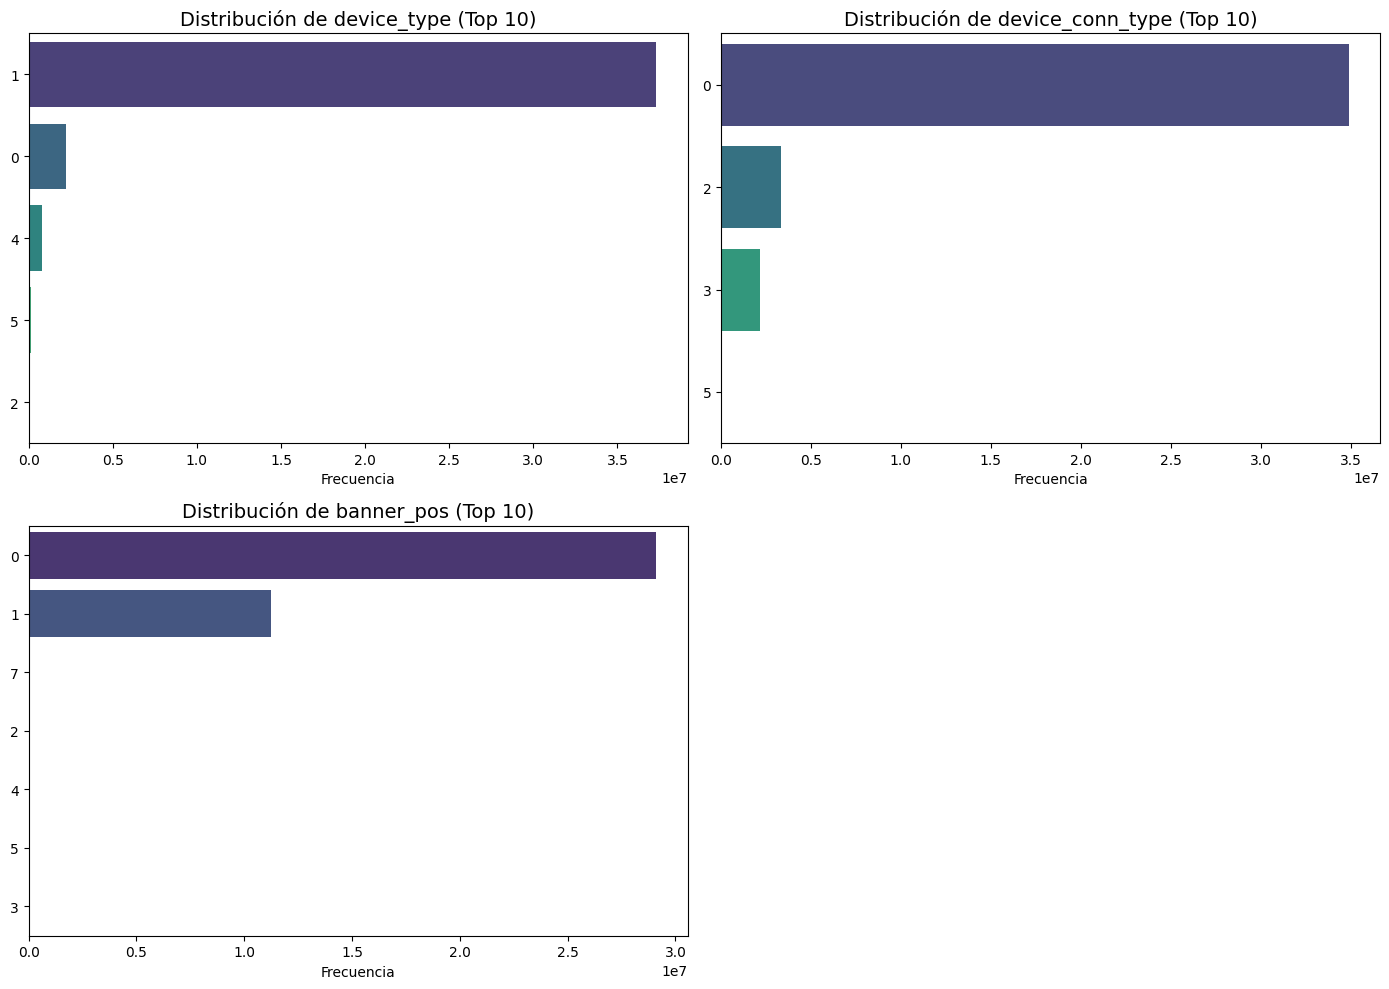

In [23]:
graficar_multiples_categoricas(df,cat)

Realizamos tambien una comparacion entre los clicks y las variables, las variables con demasiadas categorias se limitaron a solo las 20 mas importantes 

In [20]:
cols=['banner_pos', 'device_type', 'device_conn_type','franja_horaria','site_category','C1','C15','C16','C18']

--- Procesando: banner_pos ---


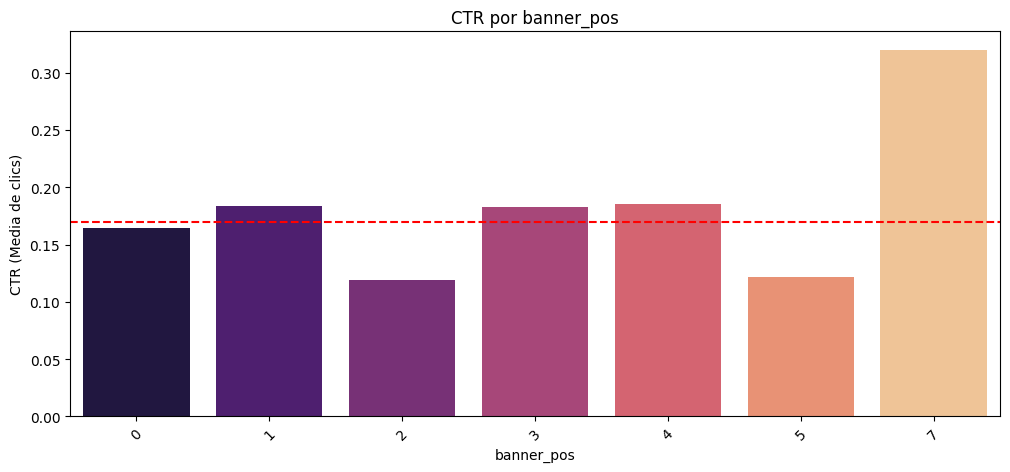

--- Procesando: device_type ---


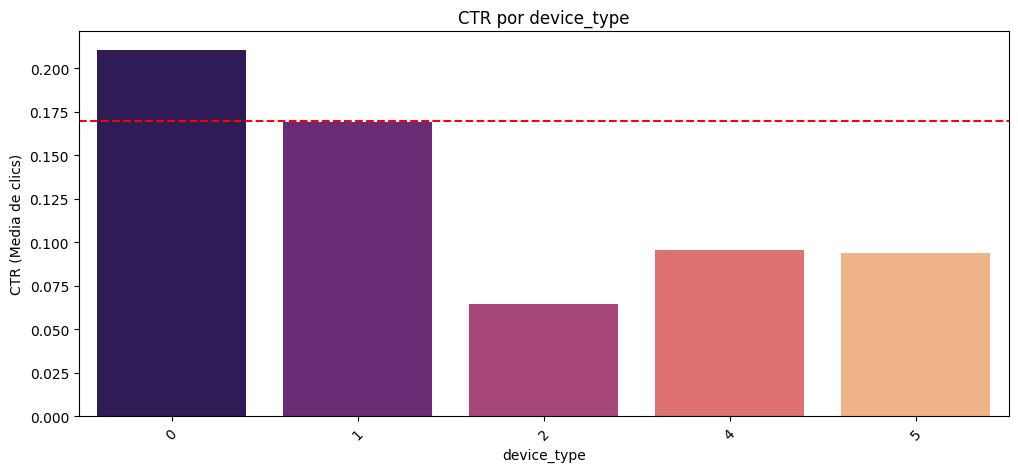

--- Procesando: device_conn_type ---


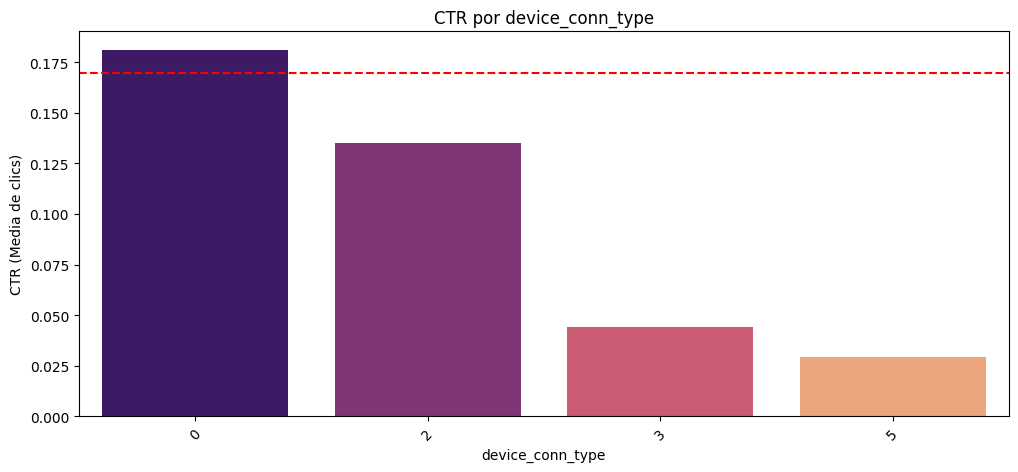

--- Procesando: franja_horaria ---


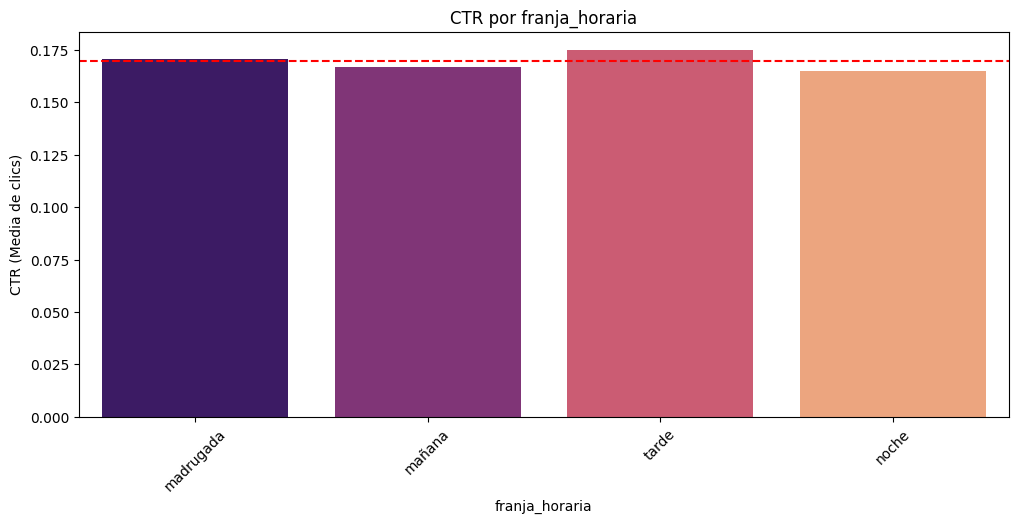

--- Procesando: site_category ---
Nota: site_category tiene 26 valores. Graficando solo el Top 20 por volumen.


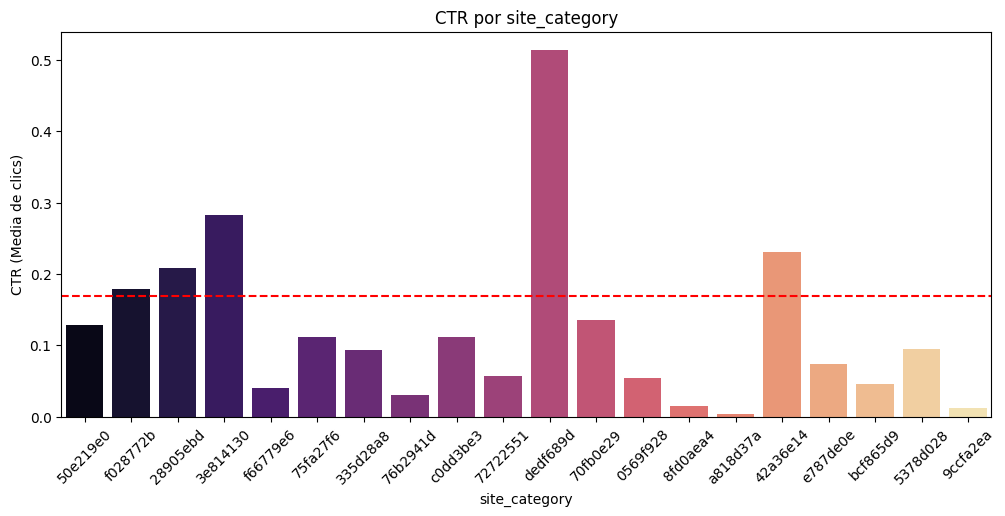

--- Procesando: C1 ---


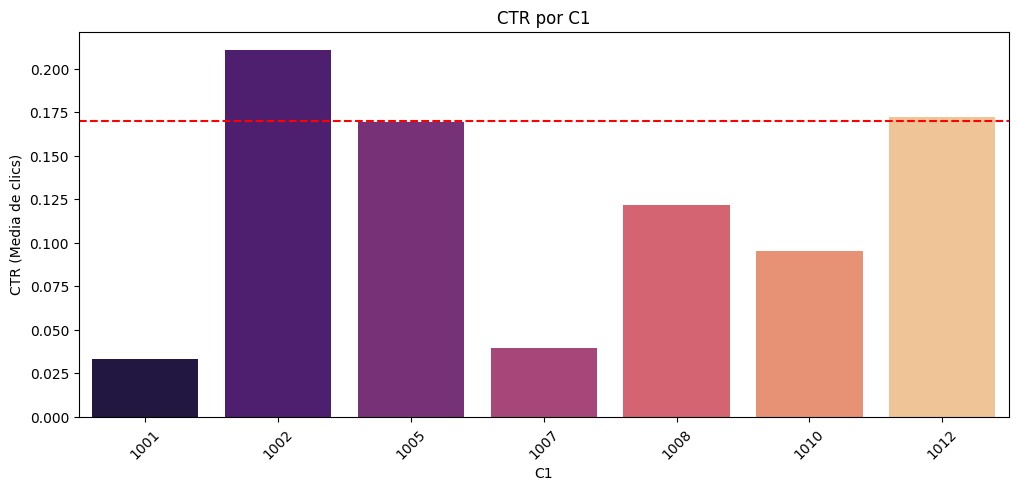

--- Procesando: C15 ---


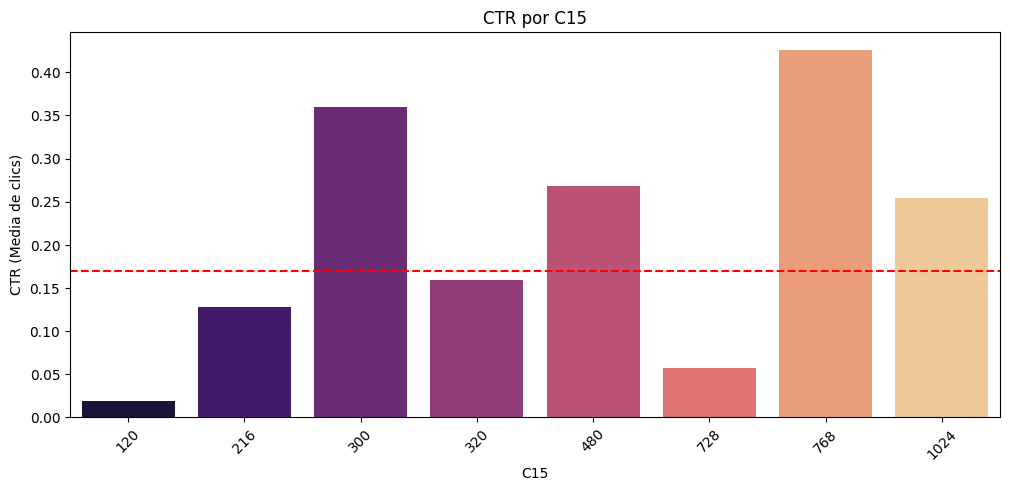

--- Procesando: C16 ---


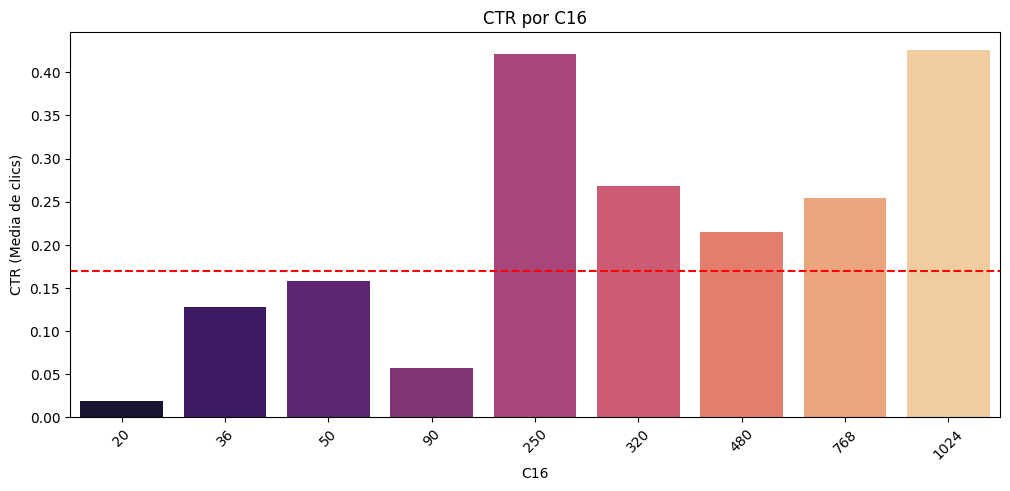

--- Procesando: C18 ---


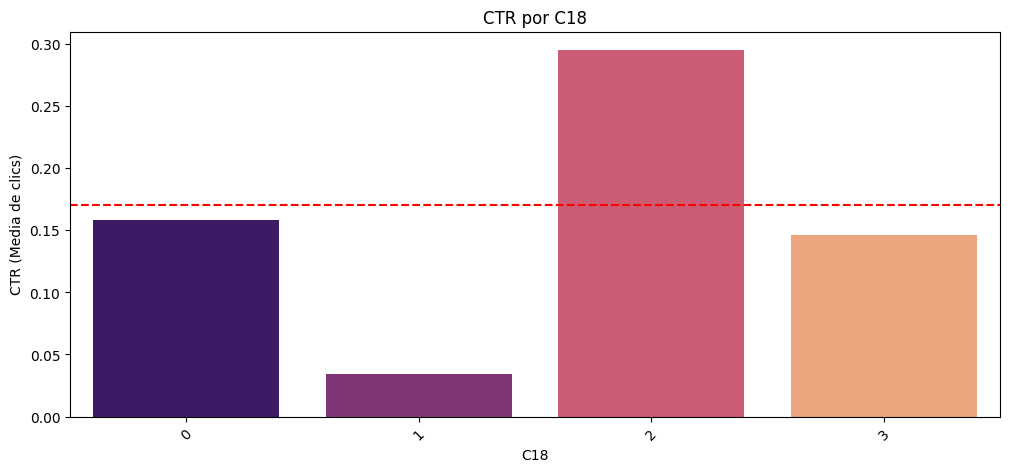

In [24]:
analizar_lote_ctr(df,cols)

Gracias a este grafico podemos observar cuales categorias son las que hay que tener mas en cuenta a la hora de hacer el modelo, porque sabemos cuales estan por encima del pormedio de las personas que dijeron que si

Realizamos un lineplot para determinar de manera mas detallada como se distribuye CTR por hora

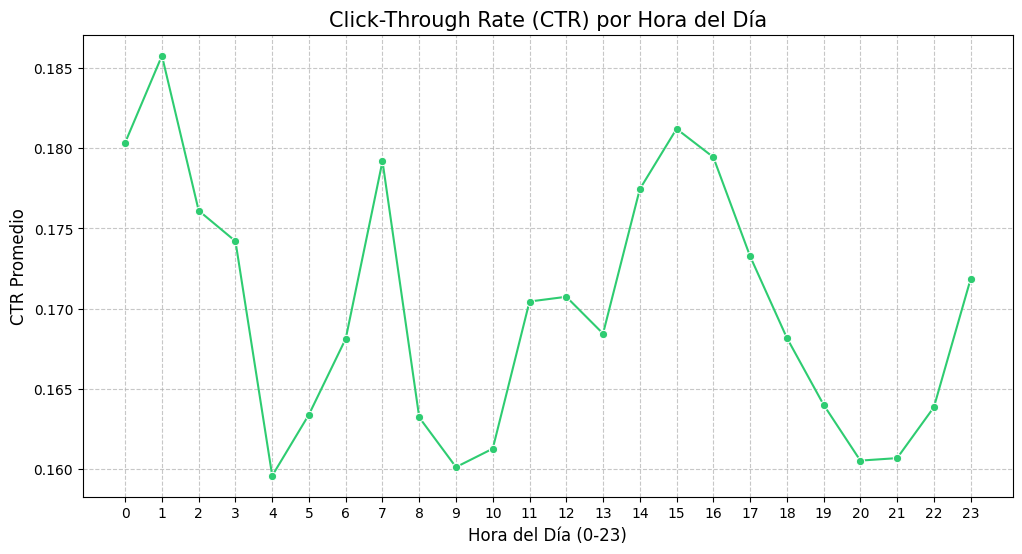

In [22]:
ctr_per_hour = df.groupby('hora_del_dia')['click'].mean().reset_index() 
plt.figure(figsize=(12, 6)) 
sns.lineplot(data=ctr_per_hour, x='hora_del_dia', y='click', marker='o', color='#2ecc71') 
plt.title('Click-Through Rate (CTR) por Hora del Día', fontsize=15) 
plt.xlabel('Hora del Día (0-23)', fontsize=12) 
plt.ylabel('CTR Promedio', fontsize=12) 
plt.grid(True, linestyle='--', alpha=0.7) 
plt.xticks(range(0, 24)) 
plt.show()

Al realizar este grafico podemos confirmar que la hora es una de las variables mas importantes para el modelo de este dataset porque a partir de ella podemos observar los picos en donde se realizan mas clicks siendo estos la 1 AM,7 AM y las 3PM con menor atencion en la noche o al final de la madrugada no hay tanta actividad,lo cual coincide con CTR de la franja horaria, lo que hace a las variables temporales variables claves para el modelado de la red neuronal.

Realizamos correlacion de las variables categoricas

In [29]:
cat_vars = [
    "C1",
    "banner_pos",
    "device_type",
    "device_conn_type",
    "C14", "C15", "C16", "C17", "C18",
    "C19", "C20", "C21",
    "franja_horaria"
]

cramers_matrix = cramers_v_matrix(
    df,
    categorical_cols=cat_vars,
    sample_size=1_000_000
)


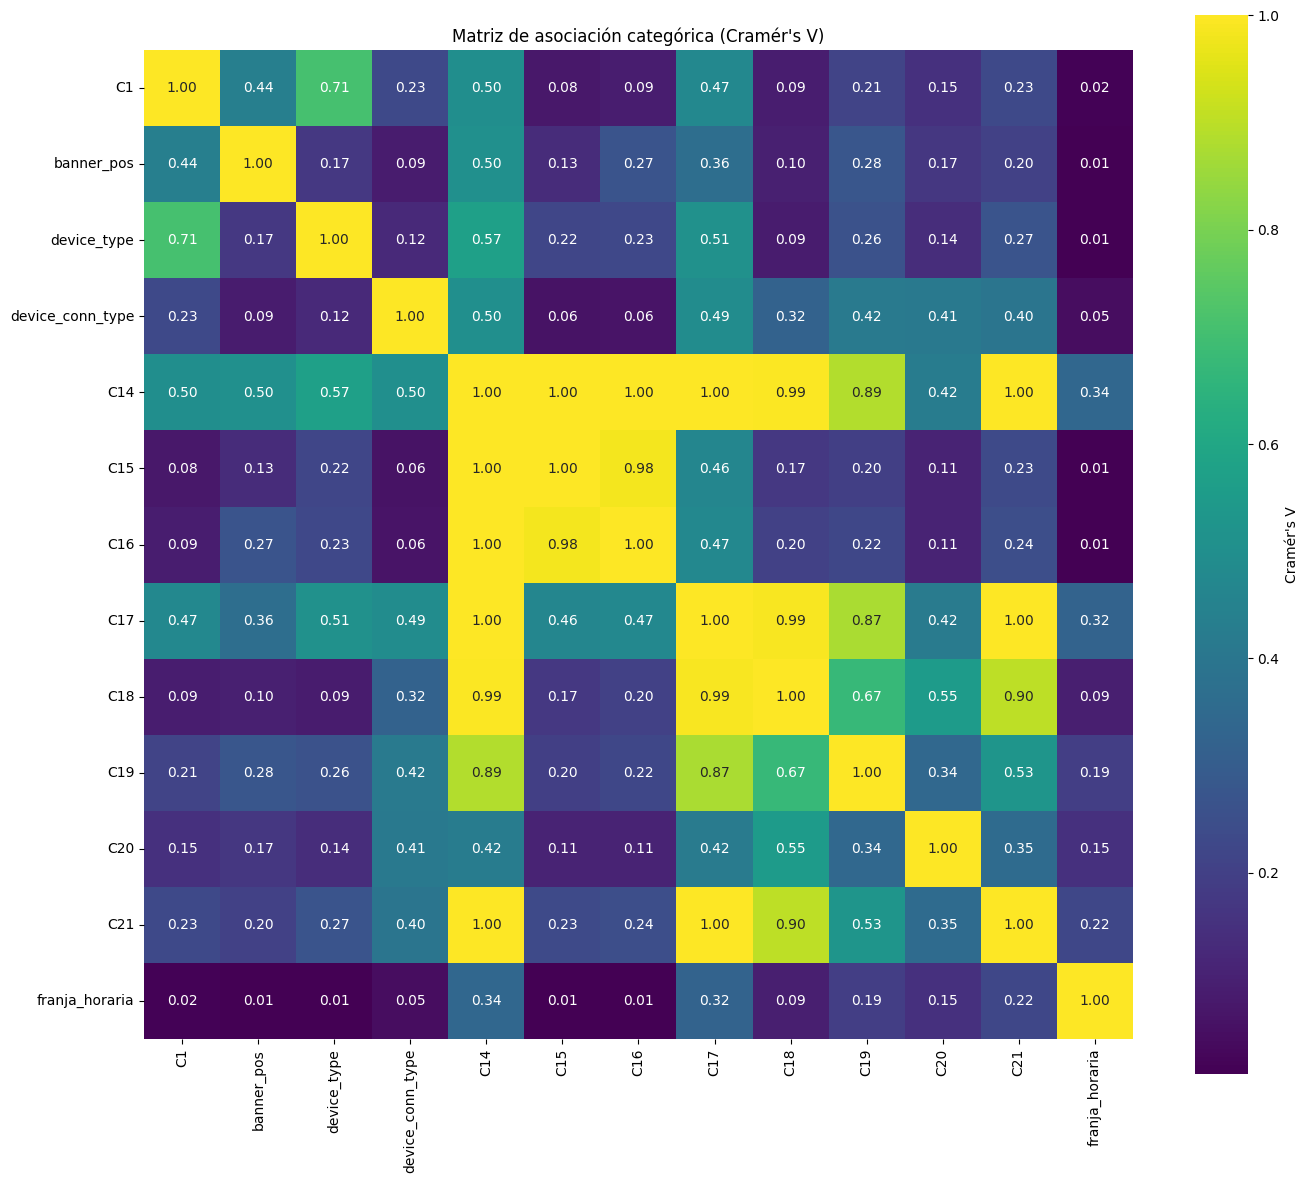

In [30]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    cramers_matrix,
    annot=True,        
    fmt=".2f",         
    cmap="viridis",
    square=True,
    cbar_kws={"label": "Cramér's V"}
)

plt.title("Matriz de asociación categórica (Cramér's V)")
plt.tight_layout()
plt.show()

Podemos observar que algunas de las variables tienen alta correlacion entre ellas, como por ejemplo entre las variables categoricas anonimas hay correlacion muy alta por lo que solo se tomaran unas pocas a la hora del modelado 

Se observa que las correlaciones no son significativas en las variables numericas, esto es esperado porque las variables categoricas son las principales en el dataset 

In [25]:
df.to_parquet('datos_procesados.parquet', engine='pyarrow', compression='snappy')